## Equalização de Peles

Este estudo tem como objetivo formular hipóteses e analisar como podemos trabalhar com algoritmos de detecção de pele e face utilizando imagens estáticas. Além disso, busca investigar se fatores fenotípicos e socio-históricos influenciam a forma como esses algoritmos detectam e se comportam quando aplicados a indivíduos reais, especialmente em ambientes com alta complexidade visual e dificuldade de interpretação.

### Especificidades e Processamento das Imagens

Conforme apresentado no arquivo README do conjunto de dados, as imagens seguem uma nomenclatura específica que pode ser utilizada para compreender melhor sua estrutura e significado. O padrão de nomenclatura é o seguinte:

**CFD-BF-999-999-(9)-N**

- **CFD** — Chicago Face Dataset  
- **B** — Etnia  
- **F** — Gênero  
- **999** — ID do modelo  
- **999** — ID da imagem  
- **(9)** — Identificador étnico  
- **N** — Expressão  

Com base nessa estrutura, podemos adaptar o comportamento dos nossos pipelines para reconhecer padrões dentro do conjunto de dados, melhorando a compreensão e o processamento das imagens.

### Histograma de Etnia

**Hipótese 1:**  
Diferentes etnias apresentam padrões distintos de histograma com base nas características da pele?

O próprio conjunto de dados fornece atributos que podem ser utilizados para analisar o comportamento dos elementos presentes no sistema. Esses atributos também podem ajudar a definir os limites e as possibilidades do modelo desenvolvido. Para isso, podemos utilizar técnicas de aprendizado supervisionado a fim de identificar padrões e extrair informações relevantes.

No código a seguir, apresentamos alguns elementos que podem ser utilizados para analisar e caracterizar as imagens.

In [6]:
# Built-in
import os
import enum
from pathlib import Path, WindowsPath
from dataclasses import dataclass
from typing import Optional, List

# Terceiros
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import sklearn
import skimage as ski
import cv2
from cv2 import UMat

ROOT_DIR = "./dataset/chicago_face_dataset/images/CFD"

### Metodologia

Na primeira etapa deste estudo, focamos na análise da distribuição das intensidades de pixels em imagens faciais entre diferentes grupos étnicos utilizando técnicas baseadas em histogramas.

Inicialmente, o conjunto de dados será organizado e separado de acordo com os rótulos de etnia fornecidos pela convenção de nomenclatura das imagens. Em seguida, cada imagem será processada utilizando a biblioteca **OpenCV (cv2)** em Python, responsável pela leitura, conversão e, quando necessário, normalização das imagens (por exemplo, redimensionamento e conversão de espaço de cor, como RGB → HSV ou YCrCb).

Para cada imagem, serão calculados histogramas de intensidade de pixels, considerando tanto representações em escala de cinza quanto canais de cor específicos relevantes para a detecção de pele. Esses histogramas representam a distribuição dos valores de pixels e funcionam como uma assinatura numérica de características visuais, como brilho, contraste e variações de tonalidade da pele.

Após a extração dos histogramas de todas as imagens pertencentes a um determinado grupo étnico, esses dados serão agregados para o cálculo de um histograma médio (média) para cada grupo. Esse histograma médio busca representar o padrão geral de distribuição daquela etnia.

Para auxiliar na análise e visualização, a biblioteca **Seaborn** será utilizada na geração de gráficos mais suaves e interpretáveis, facilitando a comparação entre as distribuições. Essas visualizações permitirão identificar tendências, sobreposições e diferenças entre os grupos.

Por fim, os histogramas médios de cada etnia serão comparados entre si, com o objetivo de identificar padrões consistentes ou divergências significativas. Essa comparação busca avaliar se diferentes grupos étnicos apresentam comportamentos distintos nos histogramas, o que pode influenciar o desempenho e possíveis vieses de algoritmos de detecção de pele.

Essa metodologia permite uma análise tanto quantitativa (cálculo e agregação dos histogramas) quanto qualitativa (comparação visual por meio de gráficos), oferecendo uma abordagem estruturada para compreender como a distribuição de pixels varia entre diferentes grupos.

In [7]:
class Ethnicity(enum.Enum):
  ASIAN_AMERICAN = "A" 
  BLACK = "B"
  CHINESE_ASIAN = "C"
  INDIAN_ASIAN = "I"
  JAPANESE_ASIAN = "J"
  LATINO = "L"
  MULTIRACIAL_AMERICAN = "M"
  WHITE = "W"

class Gender(enum.Enum):
  MALE = "M"
  FEMALE = "F"

class Expression(enum.Enum):
  NEUTRAL = "N"
  ANGRY = "A"
  FEAR = "F"
  HAPPY_CLOSE = "HC"
  HAPPY_OPEN = "HO"
  
@dataclass
class ImageFilter:
  filename: Optional[str] = None
  ethnicity: Optional[Ethnicity] = None
  gender: Optional[Gender] = None
  expression: Optional[Expression] = None
  
  @classmethod
  def from_filename(cls, filename:str) -> "ImageFilter":
    name = filename.split("/")[-1]
    name = name.split(".")[0]
    parts = name.split("-")
    
    code = parts[1]  # CFD == 0

    ethnicity = Ethnicity(code[0])
    gender = Gender(code[1])

    expression = Expression(parts[-1])

    return cls(
      filename=filename,
      ethnicity=ethnicity,
      gender=gender,
      expression=expression
    )
    
  def matches(self, other: "ImageFilter") -> bool:
    return (
      (self.ethnicity == other.ethnicity or other.ethnicity is None) and 
      (self.gender == other.gender or other.gender is None) and 
      (self.expression == other.expression or other.expression is None)
    )
    

@dataclass
class Image(ImageFilter):
  filename: Optional[str] = None
  image: bytes | list[list[int]] | None = None

class ImageProcessingPipeline:
  def __init__(self, image_directory: str = ROOT_DIR) -> None:
    self.image_path_list = []
    self.image_directory = image_directory
    self.results = []
    
  def search_images(self, image_filter: ImageFilter | None = None) -> list[Path]:
    """
    In this filter, the user gonna pass the image specs, and based on them, 
    hes gonna make a search in all the dataset for the specific characteristics
    of the image that he already determined
    """ 
    if image_filter is None:
      image_filter = ImageFilter()
        
    if type(image_filter) != ImageFilter:
      raise TypeError("The Image filter need to be a ImageFilter instance")
   
    extensions = (".jpg", ".jpeg")
    dir_path = Path(self.image_directory)
    
    for img_path in dir_path.rglob("*"):
      if img_path.is_file() and img_path.suffix.lower() in extensions:
        parsed_image = ImageFilter.from_filename(img_path.name)
        if parsed_image.matches(image_filter):
          self.results.append(img_path)
    return self.results 

In [22]:

image_filter = ImageFilter(
  ethnicity=Ethnicity.ASIAN_AMERICAN, 
  gender=Gender.FEMALE, 
  expression = Expression.NEUTRAL
)
pipeline = ImageProcessingPipeline()
pipeline.search_images(image_filter)

[WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-200/CFD-AF-200-228-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-201/CFD-AF-201-060-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-202/CFD-AF-202-122-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-203/CFD-AF-203-077-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-204/CFD-AF-204-067-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-205/CFD-AF-205-155-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-206/CFD-AF-206-079-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-207/CFD-AF-207-023-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-208/CFD-AF-208-003-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-209/CFD-AF-209-006-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-210/CFD-AF-210-050-N.jpg'),
 WindowsPath('dataset/chicago_face_dataset/images/CFD/AF-211/CFD-

From this. we have the capability to organize our project based on the image 
filters, that are gonna to determine which images we do want to choose to process
based on the filters that we have for each characteristc of the image.


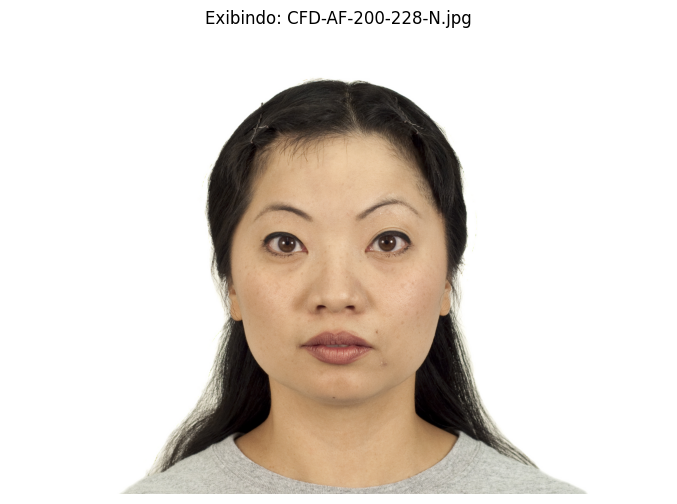

In [ ]:
results = pipeline.search_images(image_filter)
image_path = str(results[0])
plt.figure(figsize=(10, 6))
img = mpimg.imread(image_path)
plt.imshow(img)
plt.axis('off')
plt.title(f"Exibindo: {Path(image_path).name}")
plt.show()

In [ ]:
class CVPipeline:
  def __init__(self) -> None:
    self.face_classifier = None 
    self.eye_classifier = None
  
  def init_cascade_classifier(self) -> None:
    self.face_classifier = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    self.eye_classifier = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
    
  def detect_faces_in_grayscale(self, image_path: WindowsPath) -> list[tuple[int, int, int, int]]:
    if self.face_classifier is None:
      self.init_cascade_classifier() 
      
    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = self.face_classifier.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5) 
    return faces
  
  def detect_eyes_in_grayscale(self, image_path: WindowsPath) -> list[tuple[int, int, int, int]]:
    if self.eye_classifier is None:
      self.init_cascade_classifier()
    
    img = cv2.imread(str(image_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    eyes = self.eye_classifier.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    return eyes




In [ ]:
class DataVisualizationPipeline:
  def __init__(self) -> None:
    self._cv_pipeline = CVPipeline()

TypeError: DataVisualizationPipeline.plot_face_detection_grid() got an unexpected keyword argument 'show_histogram'